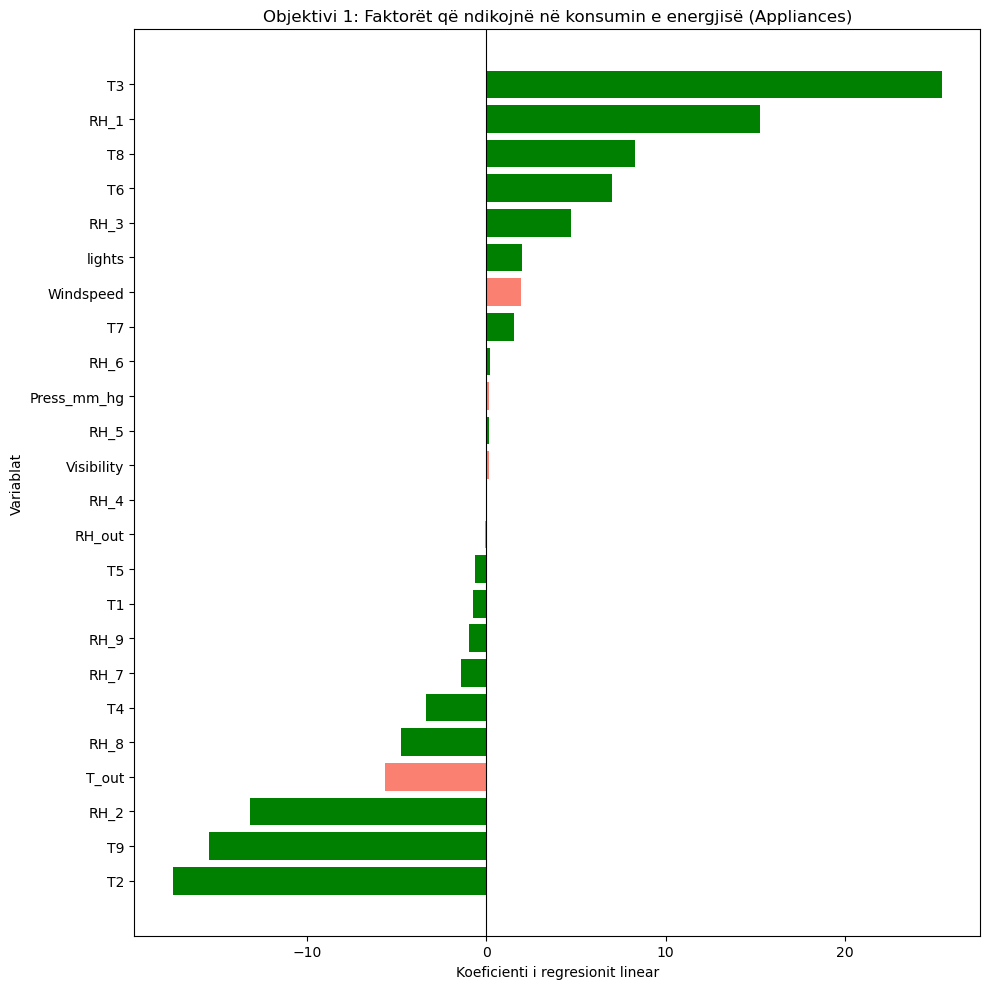

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df=pd.read_csv("energydata_complete.csv")
x = df[["T1","T2","T3","T4","T5","T6","T7","T8","T9",
        "RH_1","RH_2","RH_3","RH_4","RH_5","RH_6","RH_7","RH_8","RH_9","lights",
        "T_out","RH_out","Windspeed","Visibility","Press_mm_hg"]]
y = df["Appliances"]
modeli_linear=LinearRegression()
modeli_linear.fit(x,y)

koeficientet=pd.DataFrame({
    "Variabla": x.columns,
    "Koeficienti": modeli_linear.coef_
})

variablat_brendshme=["T1","T2","T3","T4","T5","T6","T7","T8","T9",
                     "RH_1","RH_2","RH_3","RH_4","RH_5","RH_6","RH_7","RH_8","RH_9","lights",]
variablat_jashtme=["T_out","RH_out","Windspeed","Visibility","Press_mm_hg"]

def kategoria(var):
    if var in variablat_brendshme:
        return "Brendshem"
    return "Jashtem"
koeficientet["Grupi"]=koeficientet["Variabla"].apply(kategoria)
koeficientet_sorted=koeficientet.sort_values("Koeficienti", ascending=True)
plt.figure(figsize=(10,10))
ngjyrat=koeficientet_sorted["Grupi"].map({"Brendshem":"green","Jashtem":"salmon"})
plt.barh(koeficientet_sorted["Variabla"],koeficientet_sorted["Koeficienti"],color=ngjyrat)
plt.xlabel("Koeficienti i regresionit linear")
plt.ylabel("Variablat")
plt.title("Objektivi 1: Faktorët që ndikojnë në konsumin e energjisë (Appliances)")
plt.axvline(0,color="black",linewidth=0.8)
plt.tight_layout()
plt.show()

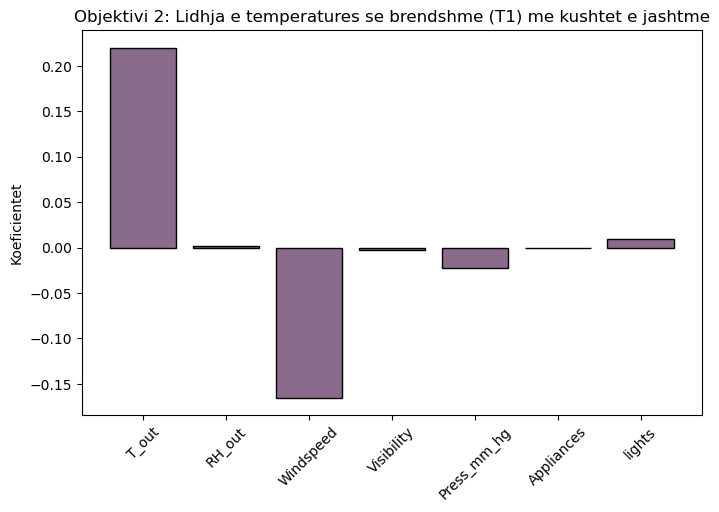

In [3]:
from sklearn.linear_model import LinearRegression
df=pd.read_csv("energydata_complete.csv")
x = df[["T_out","RH_out","Windspeed","Visibility","Press_mm_hg","Appliances","lights"]]
y = df["T1"]
modeli_linear=LinearRegression()
modeli_linear.fit(x,y)

plt.figure(figsize=(8,5))
plt.bar(x.columns,modeli_linear.coef_,color="#8b6b8c",edgecolor="black")
plt.title("Objektivi 2: Lidhja e temperatures se brendshme (T1) me kushtet e jashtme")
plt.ylabel("Koeficientet")
plt.xticks(rotation=45)
plt.show()



Konsumi mesatar pa MPC: 87.87
Konsumi mesatar me MPC: 70.29
Kursimi mesatar i energjisë: 17.57
--------------------------------------------------
Kosto mesatare pa MPC: 91.2
Kosto mesatare me MPC: 73.63
Ulja mesatare e kostos: 17.57


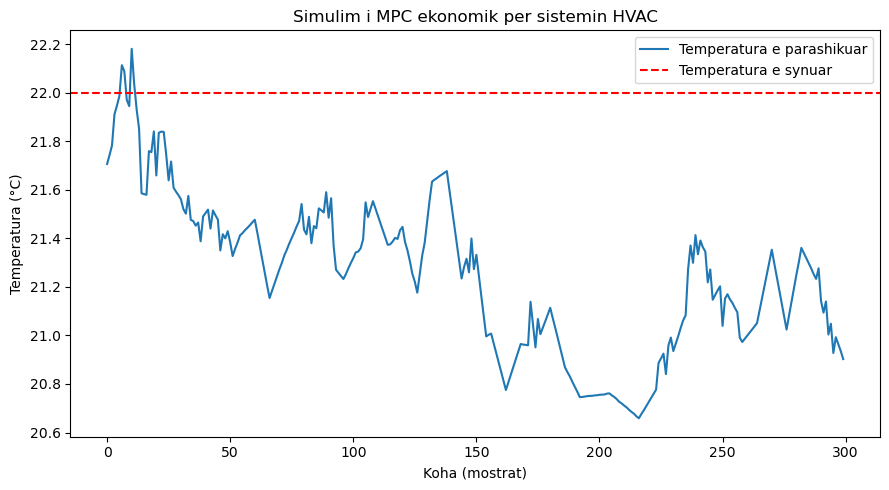

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df=pd.read_csv("energydata_complete.csv")
X = df[["T_out","RH_out","Windspeed","Visibility","Press_mm_hg","Appliances","lights"]]
y = df["T1"]

modeli_linear = LinearRegression()
modeli_linear.fit(X,y)

mostrat=300
X_sim=X.head(mostrat)
T_parashikuar = modeli_linear.predict(X_sim)

T_set = 22
alpha = 1.0
beta = 5.0

u_candidates = [0.8, 0.9, 1.0]
Konsumi = X_sim["Appliances"].values
Konsumi_mpc = Konsumi.copy()

for i in range(len(T_parashikuar)):
    costs = []
    for u in u_candidates:
        T_future = T_parashikuar[i] - 0.5 * (1-u)
        J = alpha * (Konsumi[i] * u) + beta * (T_future - T_set) ** 2
        costs.append(J)
    u_opt = u_candidates[np.argmin(costs)]
    Konsumi_mpc[i] = Konsumi[i] * u_opt

kosto_pa_mpc = []
kosto_me_mpc = []

for i in range(len(T_parashikuar)):
    J_before = alpha * Konsumi[i] + beta * (T_parashikuar[i] - T_set) ** 2
    J_after = alpha * Konsumi_mpc[i] + beta * (T_parashikuar[i] - T_set) ** 2

    kosto_pa_mpc.append(J_before)
    kosto_me_mpc.append(J_after)

mes_before = np.mean(Konsumi)
mes_after = np.mean(Konsumi_mpc)
kursimi = mes_before - mes_after

print("Konsumi mesatar pa MPC:", round(mes_before, 2))
print("Konsumi mesatar me MPC:", round(mes_after, 2))
print("Kursimi mesatar i energjisë:", round(kursimi, 2))
print("--------------------------------------------------")
print("Kosto mesatare pa MPC:", round(np.mean(kosto_pa_mpc), 2))
print("Kosto mesatare me MPC:", round(np.mean(kosto_me_mpc), 2))
print("Ulja mesatare e kostos:", round(np.mean(kosto_pa_mpc) - np.mean(kosto_me_mpc), 2))

plt.figure(figsize=(9,5))
plt.plot(T_parashikuar, label="Temperatura e parashikuar")
plt.axhline(T_set, color="red", linestyle="--", label="Temperatura e synuar")
plt.xlabel("Koha (mostrat)")
plt.ylabel("Temperatura (°C)")
plt.title("Simulim i MPC ekonomik per sistemin HVAC")
plt.legend()
plt.tight_layout()
plt.show()


